# Lorenz63 — Lorenz (1963) Strange Attractor

**Author:** Jordan Landers  
**Date:** last-modified

_Description:_ Butterfly attractor, sensitive dependence on initial conditions, lobe-switching dynamics, bifurcation from stable fixed points to chaos, Rayleigh number, Prandtl number

_Abstract_

> `Lorenz63` implements the classic three-variable convective instability model that introduced chaos theory to the atmospheric sciences. This notebook demonstrates the canonical butterfly strange attractor, sensitive dependence on initial conditions, lobe-switching dynamics, and the bifurcation from stable fixed points to full chaos as the Rayleigh number ρ exceeds ~24.74.

**Keywords:** Lorenz63, strange attractor, butterfly, chaos, sensitive dependence, lobe-switching, Rayleigh number, Prandtl number, bifurcation, convection

## Overview

`Lorenz63` implements the classic three-variable convection system (Lorenz 1963). It is the canonical example of a strange attractor and deterministic chaos: bounded, aperiodic motion with sensitive dependence on initial conditions.

### Equations

$$\frac{dx}{dt} = \sigma(y - x)$$
$$\frac{dy}{dt} = x(\rho - z) - y$$
$$\frac{dz}{dt} = xy - \beta z$$

### Parameters

| Name | Description | Default |
|---|---|---|
| `sigma` | Prandtl number — controls roll rotation | 10.0 |
| `rho` | Reduced Rayleigh number — buoyancy forcing | 28.0 |
| `beta` | Geometric factor | 8/3 |

All three accept a `float`, callable `(t)` / `(t, state)`, or `cc.Forcing`.
State variables: `x`, `y`, `z`. No diagnostic variables.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import climatecritters as cc
from climatecritters.model_critters.lorenz import Lorenz63

## Canonical attractor

In [2]:
# sigma=10, rho=28, beta=8/3 — the classic parameter set for the strange attractor
model = Lorenz63()
output = model.integrate(t_span=(0, 100), y0=[-8.0, 8.0, 27.0], method='RK45')

x = output.state_variables['x']
y = output.state_variables['y']
z = output.state_variables['z']
t = output.time

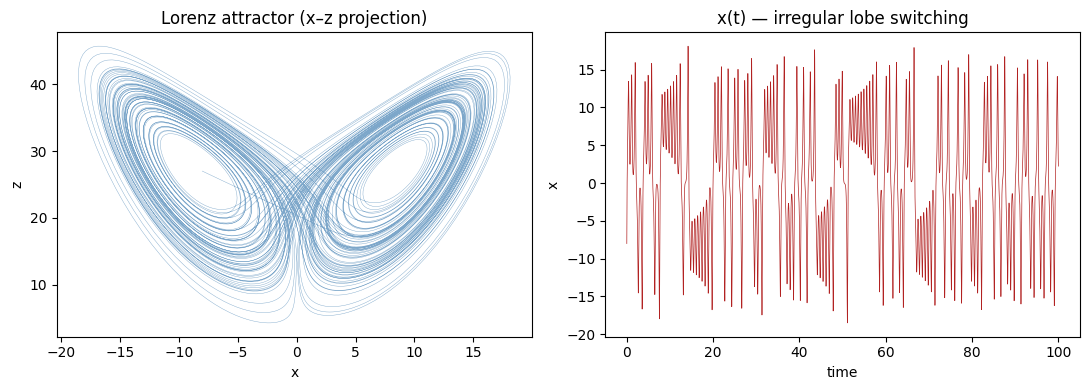

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# x-z phase portrait — the butterfly attractor
axes[0].plot(x, z, lw=0.3, alpha=0.7, color='steelblue')
axes[0].set_xlabel('x'); axes[0].set_ylabel('z')
axes[0].set_title('Lorenz attractor (x\u2013z projection)')

# x(t) time series — irregular switching between the two lobes
axes[1].plot(t, x, lw=0.5, color='firebrick')
axes[1].set_xlabel('time'); axes[1].set_ylabel('x')
axes[1].set_title('x(t) — irregular lobe switching')

plt.tight_layout(); plt.show()

**Figure.** Left: the butterfly attractor in the x–z plane. The two lobes correspond to the neighbourhoods of the two unstable fixed points $C^\pm$. Trajectories spiral outward from one lobe, hop to the other, spiral outward again — never repeating. Right: $x(t)$ shows irregular switching between positive and negative values; the timing of each hop is unpredictable despite the system being fully deterministic.

### x, y, z time series

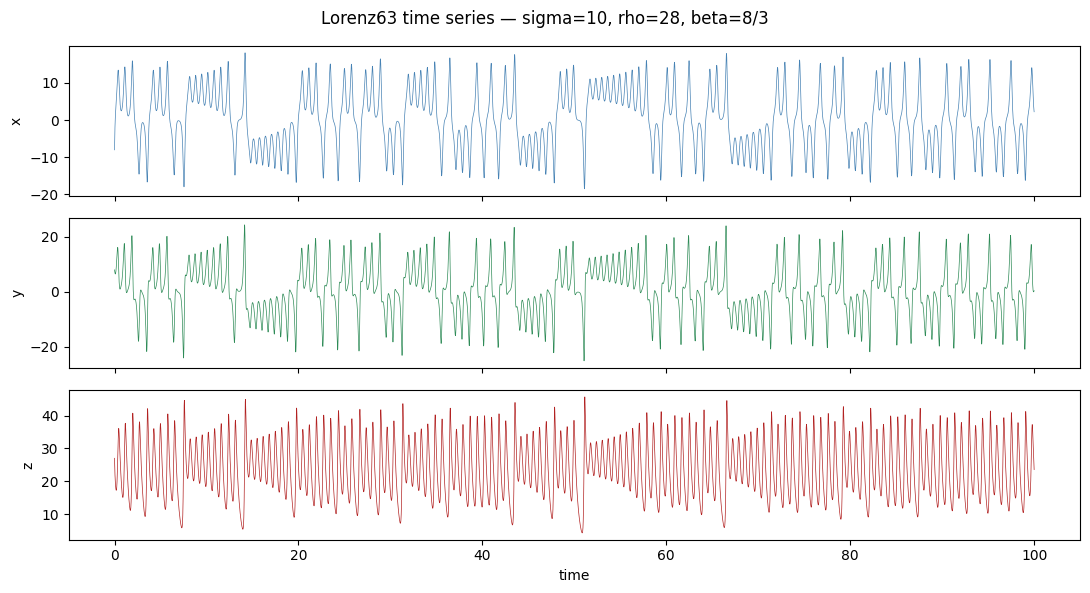

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for ax, var, color, label in zip(axes,
                                  [x, y, z],
                                  ['steelblue', 'seagreen', 'firebrick'],
                                  ['x', 'y', 'z']):
    ax.plot(t, var, lw=0.5, color=color)
    ax.set_ylabel(label)

axes[-1].set_xlabel('time')
fig.suptitle('Lorenz63 time series — sigma=10, rho=28, beta=8/3')
plt.tight_layout(); plt.show()

**Figure.** All three variables exhibit the same irregular switching. $x$ and $y$ have similar amplitudes and are loosely correlated; $z$ is always positive (near the top of the attractor when $x$, $y$ are large, dipping toward $\rho - 1 \approx 27$ at the lobe centres). The aperiodic structure is the hallmark of deterministic chaos: bounded motion with a positive Lyapunov exponent.

## The `rho` parameter

`rho` is the reduced Rayleigh number. It controls the qualitative behaviour of the system:

- **rho < 1**: the origin is the only stable fixed point — all trajectories decay to zero.
- **1 < rho < 24.74**: two stable fixed points at $C^\pm = (\pm\sqrt{\beta(\rho-1)},\; \pm\sqrt{\beta(\rho-1)},\; \rho-1)$. Trajectories spiral in and settle.
- **rho > 24.74**: the fixed points become unstable — the strange attractor appears.

The default `rho=28` is well into the chaotic regime.


In [5]:
# Same initial condition and run length — only rho changes
y0 = [-8.0, 8.0, 27.0]

m_stable = Lorenz63(rho=10)
out_stable = m_stable.integrate(t_span=(0, 50), y0=y0, method='RK45')

m_chaos = Lorenz63(rho=28)
out_chaos = m_chaos.integrate(t_span=(0, 50), y0=y0, method='RK45')

# Fixed-point location for rho=10 (analytic)
beta = 8 / 3
fp = np.sqrt(beta * (10 - 1))
print(f"rho=10 fixed point C\u207a: ({fp:.2f}, {fp:.2f}, {10 - 1})")

rho=10 fixed point C⁺: (4.90, 4.90, 9)


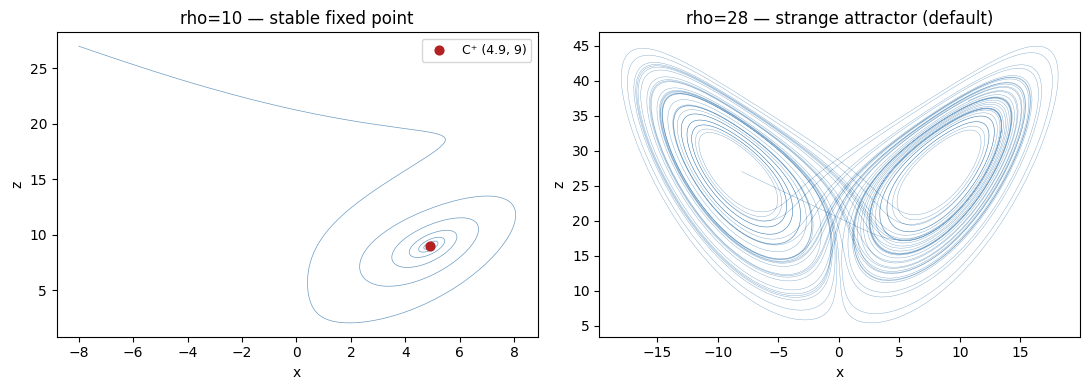

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# rho=10: trajectory spirals to C+ fixed point
xs, zs = out_stable.state_variables['x'], out_stable.state_variables['z']
axes[0].plot(xs, zs, lw=0.5, color='steelblue', alpha=0.8)
axes[0].scatter([fp], [10 - 1], color='firebrick', s=40, zorder=5, label=f'C\u207a ({fp:.1f}, {10-1})')
axes[0].set_xlabel('x'); axes[0].set_ylabel('z')
axes[0].set_title('rho=10 — stable fixed point')
axes[0].legend(fontsize=9)

# rho=28: strange attractor
xc, zc = out_chaos.state_variables['x'], out_chaos.state_variables['z']
axes[1].plot(xc, zc, lw=0.3, alpha=0.7, color='steelblue')
axes[1].set_xlabel('x'); axes[1].set_ylabel('z')
axes[1].set_title('rho=28 — strange attractor (default)')

plt.tight_layout(); plt.show()

**Figure.** Left ($\rho=10$): the trajectory spirals into the stable fixed point $C^+$ (red dot) — no chaos, just damped oscillations converging to a steady state. Right ($\rho=28$): the fixed points are unstable; the trajectory orbits both lobes indefinitely. The qualitative change at $\rho \approx 24.74$ is a subcritical Hopf bifurcation that destabilises $C^\pm$ and creates the strange attractor.

## Solver notes

RK45 is appropriate for this model at default parameters. The system is not stiff.

**`t_span` must start at 0 or later.** The model internally appends to the time array only when `t > 0`; a negative start time will leave a gap in the output. For all standard use cases `t_span=(0, T)` is correct.

**Trajectories are not reproducible across runs with random initial conditions.** The strange attractor is an invariant set — its shape is preserved — but the precise path through it is exponentially sensitive to the initial condition. Two runs from nearby but different starting points will diverge within a few time units.
